<div style='display: flex; align-items: center; justify-content: space-between;'>

  <div style='width: 15%; text-align: upper-right; padding-right: 20px; padding-left: 20px;'>
    <img src='https://i.imgur.com/85lkW3W.png'>
  </div>

  <div style='width: 80%; padding-right: 20px;'>
    
#### Taller de Gráficos en **<span style='color:#306998'>Py</span><span style='color:#FFD43B'>thon</span>** ─ Congreso **CEC<span style='color:#800000'>FA</span>** 2026
# **CÓMO HACER UN BUEN GRÁFICO SIN MORIR EN EL INTENTO**
## ✨ _ASTRONOMY EDITION_ 🔭

  </div>

</div>

---

#### Objetivos y aprendizajes esperados 🤠

Un gráfico puede parecer algo simple, pero esconde muchas decisiones importantes. En este taller abordaremos la creación de gráficos con Python y [*Matplotlib*](https://matplotlib.org) a un nivel intermedio-avanzado, aprendiendo a construir figuras mediante una analogía simple: **pensar un gráfico como un cuerpo humano**.

> **NOTA:** Este notebook es un material complementario a las slides mostradas en la sesión de taller en vivo. Tanto las slides como los archivos con datos utilizados en este notebook se encuentran en el repositorio. 

---


# 💻 **Setup**

Para este taller, recomiendo revisar los siguientes **paquetes de Python**:
[_Numpy_](https://numpy.org/), 
[_Pandas_](https://pandas.pydata.org/), 
[_Matplotlib_](https://matplotlib.org/), 
[_Astropy_](https://www.astropy.org/), 
[_Scipy_](https://scipy.org/), 
[_Seaborn_](https://seaborn.pydata.org/) y
[_Cachai_](https://cachai.readthedocs.io/en/latest/).
Recuerden que para instalarlos abrimos la consola y ejecutamos:

In [ ]:
! pip install numpy pandas matplotlib astropy scipy seaborn cachai

O bien utilizar el archivo _requirements.txt_ que se encuentra en el repositorio. Lo descargamos
y ejecutamos:

In [ ]:
! pip install -r requirements.txt

Importamos las librerías:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from   astropy.table import Table

---

# 🦴 **Parte I**: El Esqueleto

### **Paneles simples**

Intentemos hacer un gráfico con el siguiente esqueleto:

```
[A][B]
[C][D]
```

Para esto tenemos que hacer una grilla de $2 \times 2$.
Se consigue fácilemente con `plt.subplots()`.

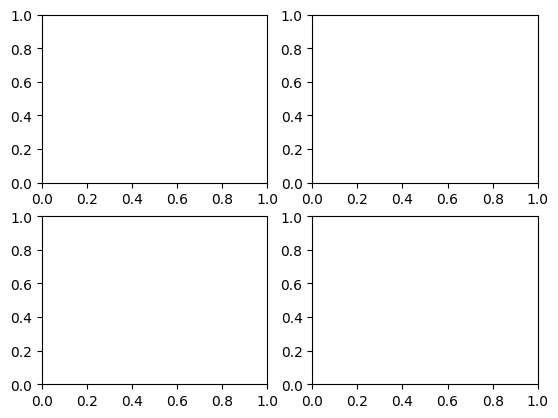

In [9]:
_,ax = plt.subplots(2,2)

Intentemos hacer un gráfico con el siguiente esqueleto:

```
[       ]
[   A   ]
[       ]
[   B   ]
```

Para esto tenemos que hacer una grilla de $2 \times 1$.
Se consigue fácilemente con `plt.subplots()` y modificando `height_ratios`.

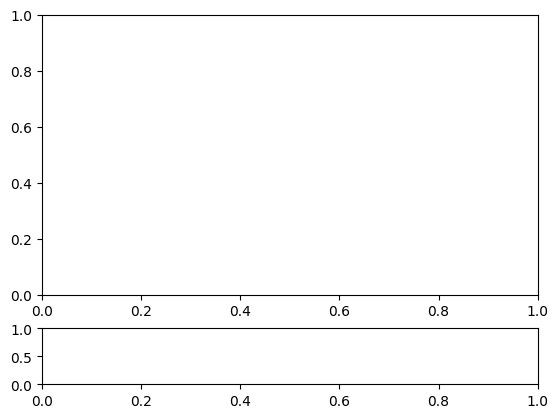

In [14]:
_,ax = plt.subplots(2,1,height_ratios=[5,1])

Intentemos hacer un gráfico con el siguiente esqueleto:

```
[  A  ][B]
[  C  ][D]
```

Para esto tenemos que hacer una grilla de $2 \times 2$.
Se consigue fácilemente con `plt.subplots()` y modificando `width_ratios`.

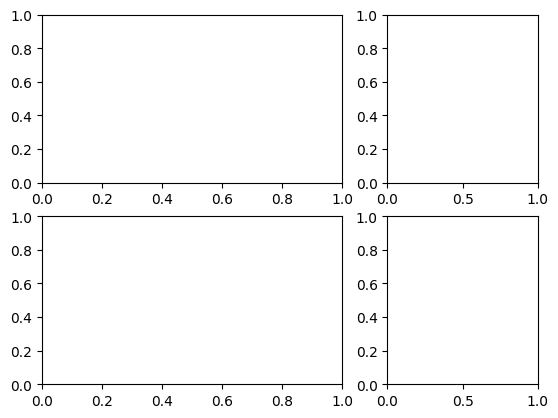

In [10]:
_,ax = plt.subplots(2,2,width_ratios=[2,1])

### **Paneles usando grillas**

Intentemos hacer un gráfico con el siguiente esqueleto:

```
[A][B][C]
[ D  ][E]
```

Para esto tenemos que hacer una grilla de $2 \times 3$, asignemos números para identificarlas:

```
[1][2][3]
[4][5][6]
```

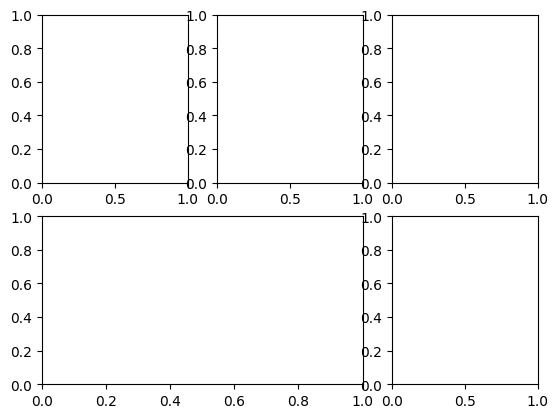

In [2]:
fig = plt.figure()

# Creamos la grilla
gs = fig.add_gridspec(nrows=2,ncols=3)

# Posicionamos nuestros paneles en la grilla
ax = [
    fig.add_subplot(gs[0,0]),   # Panel que ocupa [1]
    fig.add_subplot(gs[0,1]),   # Panel que ocupa [2] 
    fig.add_subplot(gs[0,2]),   # Panel que ocupa [3]
    fig.add_subplot(gs[1,0:2]), # Panel que ocupa [4][5]
    fig.add_subplot(gs[1,2]),   # Panel que ocupa [6]
]

Ahora intetemos un esqueleto con 1 panel principal y 3 secundarios, de esta forma:

```
[     ][B]
[  A  ][C]
[     ][D]
```
Necesitamos una grilla $3 \times 3$

```
[1][2][3]
[4][5][6]
[7][8][9]
```

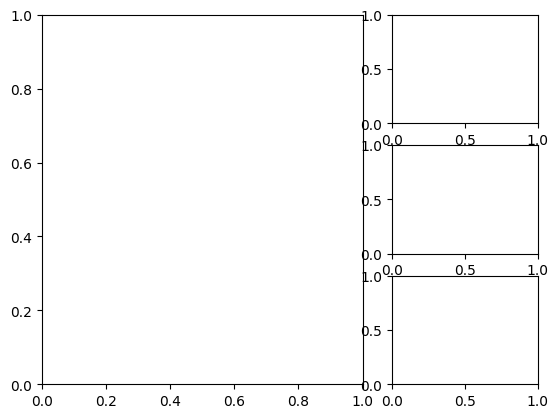

In [ ]:
fig = plt.figure()

# Creamos la grilla
gs = fig.add_gridspec(nrows=3,ncols=3)

# Posicionamos nuestros paneles en la grilla
ax = [
    fig.add_subplot(gs[:,0:2]), # Panel que ocupa [1][2], [4][5] y [7][8]
    fig.add_subplot(gs[0,2]),   # Panel que ocupa [3] 
    fig.add_subplot(gs[1,2]),   # Panel que ocupa [6]
    fig.add_subplot(gs[2,2]),   # Panel que ocupa [9]
]


### **¿Cómo implementar espacio en blanco entre paneles?**

Dos opciones, usar `plt.tight_layout()`, o `plt.subplots_adjust()`.

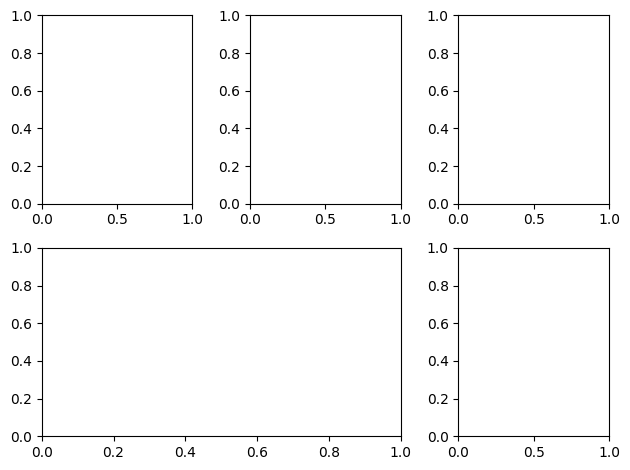

In [24]:
fig = plt.figure()

gs = fig.add_gridspec(nrows=2,ncols=3)

ax = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[1,0:2]),
    fig.add_subplot(gs[1,2]),
]

# Aplicamos opción 1
plt.tight_layout()

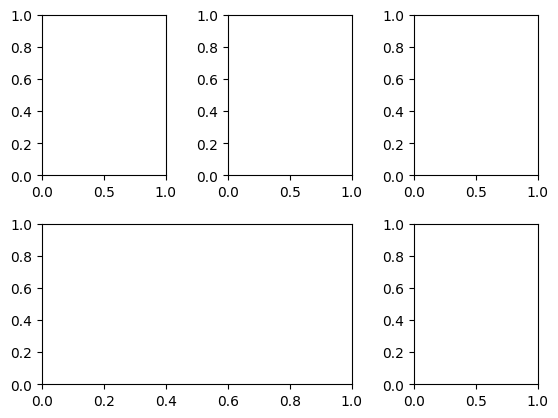

In [ ]:
fig = plt.figure()

gs = fig.add_gridspec(nrows=2,ncols=3)

ax = [
    fig.add_subplot(gs[0,0]),
    fig.add_subplot(gs[0,1]),
    fig.add_subplot(gs[0,2]),
    fig.add_subplot(gs[1,0:2]),
    fig.add_subplot(gs[1,2]),
]

# Aplicamos opción 2
plt.subplots_adjust(wspace=0.5,hspace=0.3)

---

# 💪 **Parte II**: La Musculatura

In [ ]:
datos1 = Table.read('datos_notebook/magnitud_log.csv')
datos2 = Table.read('datos_notebook/mgfe_feh.csv')

### **Cambiar escala**

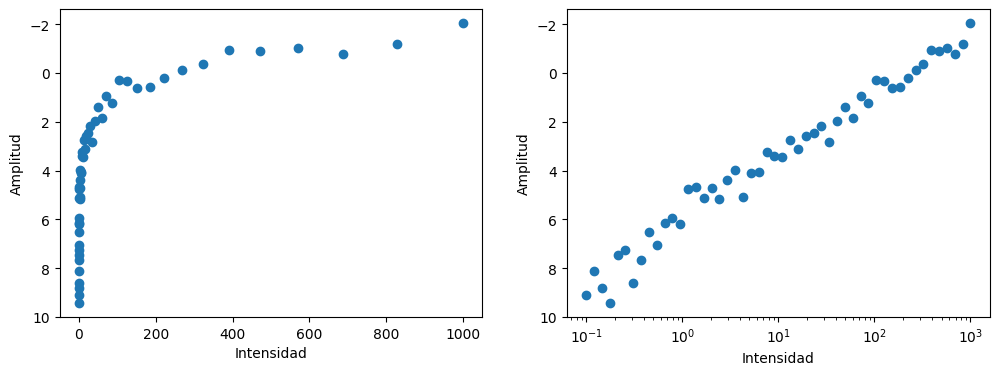

In [38]:
# Graficaremos la escala lineal y logarítmica

_,ax = plt.subplots(1,2,figsize=(12,4))

# Lineal
ax[0].scatter(datos1['intensity'],datos1['magnitude'])
ax[0].set_xlabel('Intensidad')
ax[0].set_ylabel('Amplitud')
ax[0].invert_yaxis()

# Logarítmico
ax[1].scatter(datos1['intensity'],datos1['magnitude'])
ax[1].set_xlabel('Intensidad')
ax[1].set_ylabel('Amplitud')
ax[1].invert_yaxis()
ax[1].set_xscale('log') # Acá cambiamos la escala

Hay más escalas disponibles, como: `symlog`, `asinh`, `logit`, `function`, `functionlog`.

### **Tratamiento de outliers y ajuste de límites en los ejes**

Text(-1, 0.58, '')

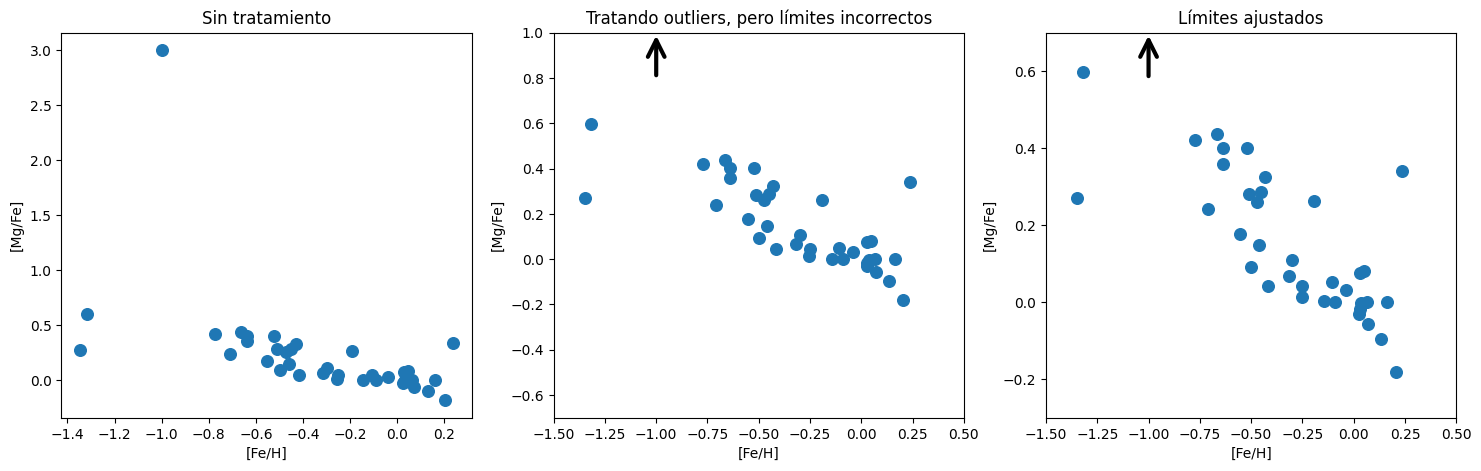

In [56]:
_,ax = plt.subplots(1,3,figsize=(18,5))

# Como los 3 tienen los mismos datos, podemos hacer un for
for axi in ax:
    axi.scatter(datos2['feh'],datos2['mgfe'],s=70)
    axi.set_xlabel('[Fe/H]')
    axi.set_ylabel('[Mg/Fe]')

# Sin tratar ni ajustar nada
ax[0].set_title('Sin tratamiento')

# Luego de tratar outliers
ax[1].set_title('Tratando outliers, pero límites incorrectos')
ax[1].set_xlim(-1.5,0.5)
ax[1].set_ylim(-0.7,1)
# Con annotate podemos crear una flecha
ax[1].annotate(
    '', 
    xy=(-1,1),       # Punta de la flecha
    xytext=(-1, 0.8), # Cola de la flecha
    arrowprops=dict(
        arrowstyle='->',
        linewidth=3,
        color='black',
        mutation_scale=30
    )
)


# Luego de tratar outliers y ajustar límites
ax[2].set_title('Límites ajustados')
ax[2].set_xlim(-1.5,0.5)
ax[2].set_ylim(-0.3,0.7)
ax[2].annotate(
    '', 
    xy=(-1,0.7),
    xytext=(-1, 0.58),
    arrowprops=dict(
        arrowstyle='->',
        linewidth=3,
        color='black',
        mutation_scale=30
    )
)

### **Colorbars**

In [58]:
# Datos de ejemplo
x = np.random.rand(20)
y = np.random.rand(20)
c = np.random.rand(20)

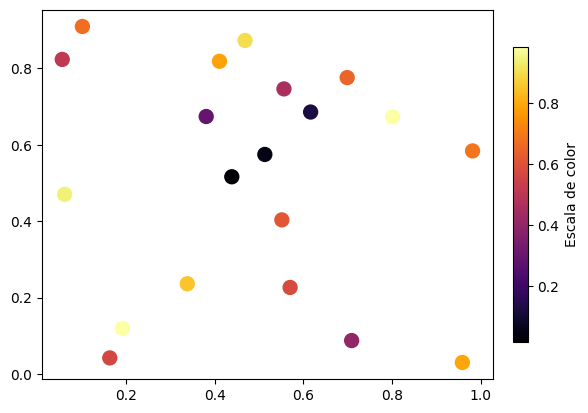

In [68]:
_,ax = plt.subplots()

# Scatter con colormap 
sc = ax.scatter(x,y,c=c,s=100,cmap='inferno')

# Colorbar básica
cbar = plt.colorbar(
    sc,
    ax=ax,            # A qué eje está asociada
    location='right', # Ubicación: right, left, top o bottom
    fraction=0.05,    # Ancho relativo de la colorbar
    pad=0.04,         # Separación respecto al eje
    shrink=0.8        # Esto hace la colorbar más corta (1 = tamaño completo)
)

cbar.set_label('Escala de color')

### **Leyendas**

In [69]:
# Datos de ejemplo
x = np.linspace(0, 10, 100)

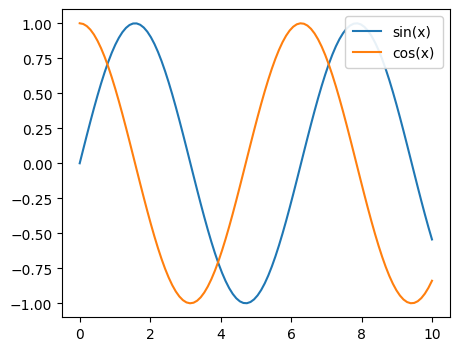

In [ ]:
fig, ax = plt.subplots(figsize=(5,4))

# Curvas de ejemplo
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)')

# Leyenda
ax.legend(
    loc='upper right',      # Posición básica
    frameon=True,           # Queremos un marco para la leyenda?
    framealpha=0.9,         # Transparencia del fondo
    fontsize=10,            # Tamaño de la letra
    ncol=1,                 # Número de columnas
    handlelength=2,         # Largo de las líneas en la leyenda
    borderpad=0.6           # Padding interno
)

plt.show()

¿Cómo muevo la leyenda fuera del panel? Usamos `bbox_to_anchor`.

En este caso usaremos 2 columnas en la leyenda, y la ubicaremos al centro abajo,
`bbox_to_anchor` funciona con porcentajes como `(x,y)` respecto lo que usemos en `loc`,
por nuestro caso, queremos que esté en el 50% del eje X, y en un -20% del eje Y:

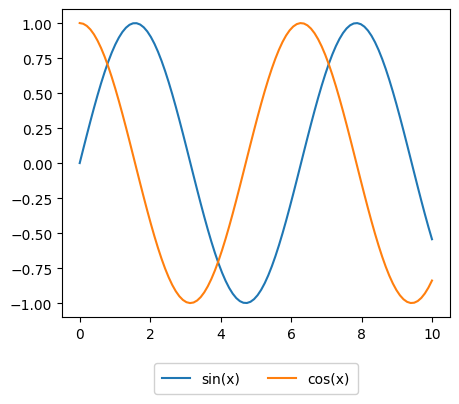

In [80]:
fig, ax = plt.subplots(figsize=(5,4))

# Curvas de ejemplo
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)')

# Leyenda
ax.legend(
    loc='center', # Cambiamos esto a center (es mas facil intuir los porcentajes del bbox_to_anchor)
    frameon=True,
    framealpha=0.9,
    fontsize=10,
    ncol=2,
    handlelength=2,
    borderpad=0.6,
    bbox_to_anchor=(0.5,-0.2), # Acá!
)

plt.show()

Hay más opciones aun para personalizaar la leyenda!

### **_Mini-plots_**

Para agregar un miniplot usamos `ax.inset_axes()`. Este recibe los límites o `bounds`, que como
la leyenda, funciona con porcentajes. Notar que la posición se mide respecto a la esquina inferior
izquierda del panel. En este caso, los porentajes corresponden a:

`bounds=[posicion_x, posicion_y, ancho, alto]`

Acá agregaremos un miniplot que está ubicado en el 20% de X (`posicion_x=0.2`),
40% de Y (`posicion_y=0.4`), el ancho será el 50% del largo de X (`ancho=0.5`),
y el alto será el 30% del largo de Y (`alto=0.3`), es decir:

`bounds=[0.2, 0.4, 0.5, 0.3]`


<Axes: label='inset_axes'>

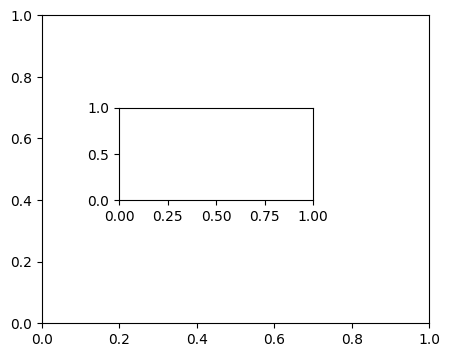

In [89]:
_, ax = plt.subplots(figsize=(5,4))

ax.inset_axes(bounds=[0.2, 0.4, 0.5, 0.3],zorder=0)

### **_Ticks_ y _Spines_**

Qué le estamos haciendo a los ticks?
- `direction`: cambia hacia dónde se orientan los ticks, `in`, `out` o ambos (`inout`)
- `length`: cambia el largo de las marcas
- `width`: cambia el ancho de las marcas
- `which`: nos permite elegir qué queremos ajustar, los ticks mayores (`major`), menores (`minor`) o ambos (`both`)

Y los spines? Para cambiar un spine debemos elegirlo, tenemos las opciones `top`, `bottom`, `left` y `right`.
Podemos hacer cosas como desactivarlos (`.set_visible(False)`) o cambiar su grosor (`.set_linewidth()`).

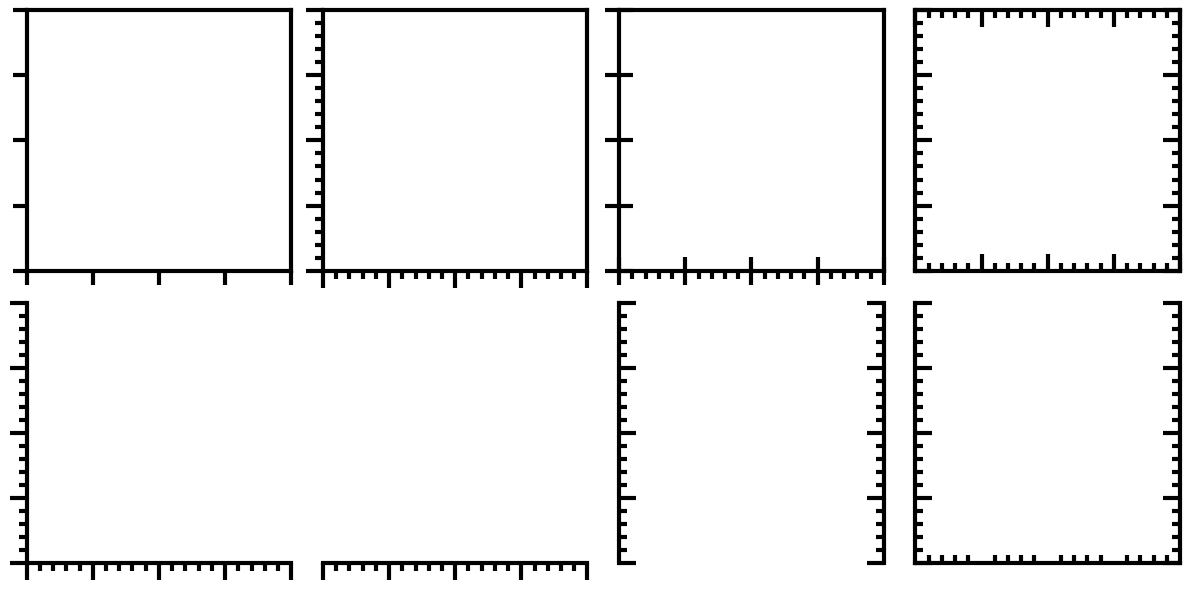

In [102]:
_,axs = plt.subplots(2,4,figsize=(12,6))

# En este for aumentaremos el largo y grosor de los ticks y spines de todos los paneles,
# para visualizar mejor los cambios.
# Además sacaremos los números para enfocarnos únicamente en los ejes.
for ax in list(np.hstack(axs)):
    ax.set_xticks([0,1,2,3,4],[])
    ax.set_yticks([0,1,2,3,4],[])
    for s in ax.spines: ax.spines[s].set_linewidth(3) 

# Solo major ticks afuera
axs[0,0].tick_params(direction='out',length=10,width=3,which='major')

# Major y minor ticks afuera
axs[0,1].minorticks_on()
axs[0,1].tick_params(direction='out',length=12,width=3,which='major')
axs[0,1].tick_params(direction='out',length=6,width=3,which='minor')

# Major afuera y adentro, y minor afuera solo abajo abajo
axs[0,2].minorticks_on()
axs[0,2].tick_params(direction='inout',length=20,width=3,which='major')
axs[0,2].tick_params(direction='out',length=6,width=3,which='minor',left=False)

# Major y minor ticks adentro
axs[0,3].minorticks_on()
axs[0,3].tick_params(direction='in',length=12,width=3,which='major',right=True,top=True)
axs[0,3].tick_params(direction='in',length=6,width=3,which='minor',right=True,top=True)

# Solo spines izquierda abajo
axs[1,0].minorticks_on()
axs[1,0].tick_params(direction='out',length=12,width=3,which='major')
axs[1,0].tick_params(direction='out',length=6,width=3,which='minor')
axs[1,0].spines[['top','right']].set_visible(False)

# Solo spines abajo
axs[1,1].minorticks_on()
axs[1,1].tick_params(direction='out',length=12,width=3,which='major',left=False)
axs[1,1].tick_params(direction='out',length=6,width=3,which='minor',left=False)
axs[1,1].spines[['top','right','left']].set_visible(False)


# Solo spines de los lados
axs[1,2].minorticks_on()
axs[1,2].tick_params(direction='in',length=12,width=3,which='major',bottom=False,right=True)
axs[1,2].tick_params(direction='in',length=6,width=3,which='minor',bottom=False,right=True)
axs[1,2].spines[['top','bottom']].set_visible(False)

# Tipo U
axs[1,3].minorticks_on()
axs[1,3].tick_params(direction='in',length=12,width=3,which='major',bottom=False,right=True)
axs[1,3].tick_params(direction='in',length=6,width=3,which='minor',bottom=True,right=True)
axs[1,3].spines[['top']].set_visible(False)

plt.tight_layout()

---

# 🎨 **Parte III**: La Piel

In [ ]:
# Cargamos algunos datos
datos = Table.read('datos_notebook/catalogo.csv')

### **Canales y multifuncionalidad**

Vamos a ver como aplicar varios canales/atributos a partir de un set de datos de varias variables.

Representaremos lo siguiente:

- **Posición en X**: RA
- **Posición en Y**: DEC
- **Color**: Temperatura efectiva
- **Tamaño (Área)**: Edad
- **Forma**: Componente galáctico al que pertenece


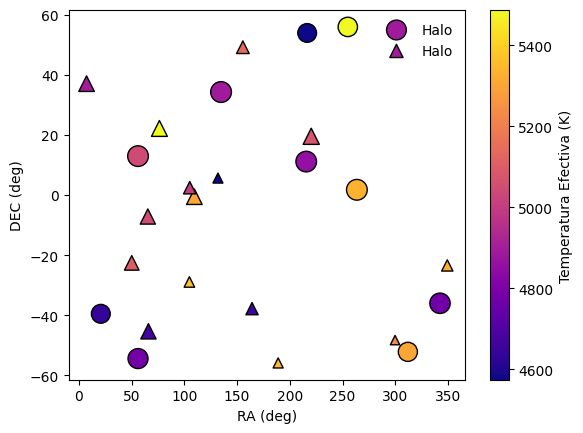

In [ ]:
# Fijamos un tamaño base de marcador de 30, y lo hacemos proporcional a la edad
sizes = 30 + 15 * datos['Edad']

_,ax = plt.subplots()

# Hacemos una máscara para el Halo
mask_halo = (datos['Componente'] == 'halo')

sc1 = ax.scatter(
    datos['RA'][mask_halo],     # Posición en X
    datos['DEC'][mask_halo],    # Posición en Y
    c=datos['Teff'][mask_halo], # Color
    s=sizes[mask_halo],         # Tamaño
    marker='o',                 # Forma
    cmap='plasma',
    edgecolor='black',
    label='Halo'
)

# Hacemos una máscara para el Halo
mask_disk = (datos['Componente'] == 'disk')

sc2 = ax.scatter(
    datos['RA'][mask_disk],     # Posición en X
    datos['DEC'][mask_disk],    # Posición en Y
    c=datos['Teff'][mask_disk], # Color
    s=sizes[mask_disk],         # Tamaño
    marker='^',                 # Forma
    cmap='plasma',
    edgecolor='black',
    label='Halo'
)

ax.set_xlabel('RA (deg)')
ax.set_ylabel('DEC (deg)')

ax.legend(frameon=False)

cbar = plt.colorbar(sc1, ax=ax)
cbar.set_label('Temperatura Efectiva (K)')

plt.show()

A este gráfico aun le faltan mejoras visuales, pero esto ya nos sirve para saber cómo controlar
los atributos y tener elementos multifuncionales.

### **Fuentes personalizadas**

Una forma de hacerlo es actualizando los `rcParams`.

En este ejemplo usaremos la fuente sans-serif "Lato", y para texto monoespaciado
usaremos la fuente "Roboto Mono". Además definiremos que nuestro tamaño de letra predeterminado
será 15 puntos.

> **Nota:** Esto depende de las fuentes instaladas en tu computador, pero usualmente hay fuentes
universales que la mayoría tiene pre-instaladas.

Hagamos un gráfico de prueba antes de cambiarlo:

In [2]:
# Datos de ejemplo
x = np.linspace(0, 10, 100)

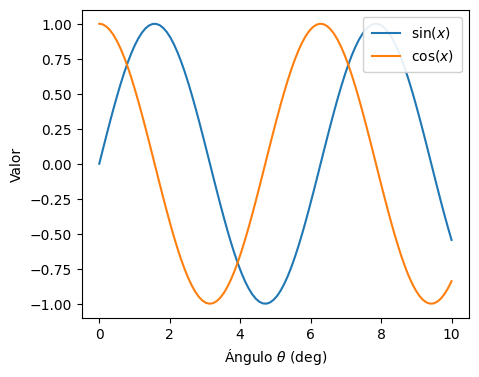

In [3]:
fig, ax = plt.subplots(figsize=(5,4))

ax.plot(x, np.sin(x), label=r'$\sin(x)$')
ax.plot(x, np.cos(x), label=r'$\cos(x)$')

ax.set_xlabel(r'Ángulo $\theta$ (deg)')
ax.set_ylabel('Valor')

ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    fontsize=10,
    ncol=1,
    handlelength=2,
    borderpad=0.6     
)

plt.show()

Lo cambiamos:

In [4]:
params = {
    'font.family'      : f'sans-serif',
    'font.sans-serif'  : f'Lato',
    'font.monospace'   : f'Roboto Mono',
    'font.cursive'     : f'Kalam',    
    'mathtext.fontset' : f'custom',
    'mathtext.rm'      : f'Lato',
    'mathtext.it'      : f'Lato:italic',
    'mathtext.bf'      : f'Lato:bold',
    'mathtext.bfit'    : f'Lato:italic:bold',
    'mathtext.default' : f'it',
    'font.size'        : 15,
    'legend.fontsize'  : 15,
}

plt.rcParams.update(params)

Y probamos nuevamente:

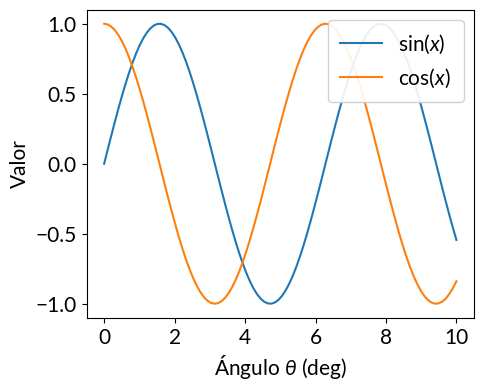

In [5]:
fig, ax = plt.subplots(figsize=(5,4))

# Curvas de ejemplo
ax.plot(x, np.sin(x), label=r'$\sin(x)$')
ax.plot(x, np.cos(x), label=r'$\cos(x)$')

ax.set_xlabel(r'Ángulo $\theta$ (deg)')
ax.set_ylabel('Valor')

# Leyenda
ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    ncol=1,
    handlelength=2,
    borderpad=0.6     
)

plt.show()

Tambien podemos cambiar algunos aspectos de la fuente directamente en el gráfico:

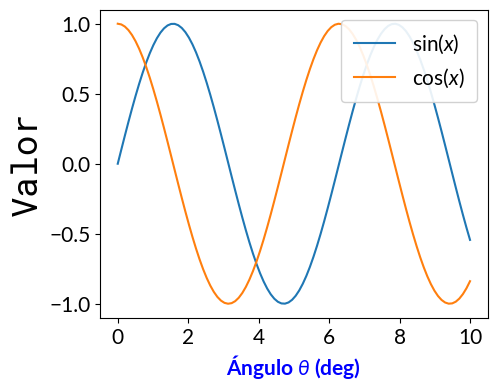

In [7]:
fig, ax = plt.subplots(figsize=(5,4))

# Curvas de ejemplo
ax.plot(x, np.sin(x), label=r'$\sin(x)$')
ax.plot(x, np.cos(x), label=r'$\cos(x)$')

# Haremos el label de X de color azul y negrita
ax.set_xlabel(r'Ángulo $\theta$ (deg)',fontdict={'color':'blue','weight':'bold'})
# Haremos el label de Y monoespaciado y más grande
ax.set_ylabel('Valor',fontdict={'family':'monospace','size':25})

# Leyenda
ax.legend(
    loc='upper right',
    frameon=True,
    framealpha=0.9,
    ncol=1,
    handlelength=2,
    borderpad=0.6     
)

plt.show()

### **Paletas de colores**

Para descubrir tu paleta de colores, te recomiendo usar la librería
[_Seaborn_](https://seaborn.pydata.org/).

In [8]:
import seaborn as sns

Para ver paletas de colores ya existentes, podemos usar `color_palette`. Lo genial es que podemos
pedir una lista de colores (util para categorizar) o un mapa de colores (util para cuantificar).

In [11]:
# Paleta de colores HLS
sns.color_palette('hls')

[(0.86, 0.3712, 0.33999999999999997),
 (0.8287999999999999, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.3712),
 (0.33999999999999997, 0.8287999999999999, 0.86),
 (0.3712, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.8287999999999999)]

In [12]:
# Ahora queremos que la paleta sea más grande
sns.color_palette('hls',n_colors=25)

[(0.86, 0.3712, 0.33999999999999997),
 (0.86, 0.496, 0.33999999999999997),
 (0.86, 0.6208, 0.33999999999999997),
 (0.86, 0.7456, 0.33999999999999997),
 (0.8496, 0.86, 0.33999999999999997),
 (0.7247999999999999, 0.86, 0.33999999999999997),
 (0.6000000000000001, 0.86, 0.33999999999999997),
 (0.47519999999999996, 0.86, 0.33999999999999997),
 (0.3503999999999999, 0.86, 0.33999999999999997),
 (0.33999999999999997, 0.86, 0.4544),
 (0.33999999999999997, 0.86, 0.5792000000000002),
 (0.33999999999999997, 0.86, 0.7040000000000001),
 (0.33999999999999997, 0.86, 0.8288),
 (0.33999999999999997, 0.7663999999999997, 0.86),
 (0.33999999999999997, 0.6415999999999997, 0.86),
 (0.33999999999999997, 0.5167999999999999, 0.86),
 (0.33999999999999997, 0.3919999999999998, 0.86),
 (0.4128000000000003, 0.33999999999999997, 0.86),
 (0.5375999999999996, 0.33999999999999997, 0.86),
 (0.6623999999999999, 0.33999999999999997, 0.86),
 (0.7871999999999999, 0.33999999999999997, 0.86),
 (0.86, 0.33999999999999997, 0.808),
 (0.86, 0.33999999999999997, 0.6831999999999999),
 (0.86, 0.33999999999999997, 0.5583999999999998),
 (0.86, 0.33999999999999997, 0.4335999999999997)]

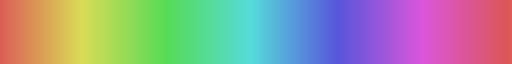

In [13]:
# Ahora lo queremos como color map
sns.color_palette('hls',as_cmap=True)

Y hay mucho más! Les recomiendo mucho visitar la documentación de Seaborn.

---

# 🛠️ **Actividad**

### **Contexto**

Durante el análisis de una población estelar joven, se detectó un comportamiento espectral inesperado en un subconjunto de estrellas tipo B. En particular, estas estrellas muestran un exceso de flujo localizado que aparece como un “monte aplanado” en el rango espectral entre 8700 y 9000 $\AA$, una región donde el continuo de este tipo de estrellas debería ser bajo.

Al ampliar el muestreo, se identificaron varias estrellas con este mismo comportamiento. Estas estrellas no solo comparten una firma espectral peculiar, sino que además ocupan una región específica del diagrama color-magnitud (CMD) y presentan propiedades químicas distintas. Una posible explicación es que se trate de un fenómeno no puramente fotosférico, asociado por ejemplo a material circumestelar, rotación rápida o procesos evolutivos particulares que afectan tanto el espectro como la química superficial.

### **Datos**

Se dispone del archivo `cecfa_catalog.csv`, que contiene un catálogo de estrellas con las siguientes columnas:

- `id`: identificador único con formato `CECFA---`, donde `---` es un número.
- `flag`: tipo de estrella, que puede tomar los valores `'normal'` o `'weird'`.
- `B-V`: color fotométrico, en unidades de magnitudes (mag).
- `M_V`: magnitud absoluta en el filtro V, en magnitudes (mag).
- `Teff`: temperatura efectiva, en Kelvin (K).
- `[N/H]`: abundancia química de nitrógeno, en dex.

Además, se entregan dos espectros observacionales en formato CSV:

- `spec_CECFA041_normal.csv`: espectro de una estrella tipo B normal.
- `spec_CECFA181_weird.csv`: espectro de una estrella con el fenómeno del “monte aplanado”.

Ambos archivos espectrales contienen las columnas:

- `wave`: longitud de onda en $\AA$
- `flux`: flujo espectral en $\mathrm{erg}$ $\AA^{-1}$ $s^{-1}$ $\mathrm{cm}^{-2}$

### **Objetivo**

El objetivo es construir una figura que comunique claramente el descubrimiento de esta subpoblación estelar. Ustedes deben decidir cuántos paneles usar y qué mostrar en cada uno, aplicando los principios discutidos en el taller. La figura debe responder a la pregunta científica, ser honesta con los datos, clara en su mensaje y cuidada en su diseño visual.


### **_Hints_**

Algunas ideas de gráficos que pueden resultar útiles incluyen:

- Un diagrama color-magnitud (CMD), por ejemplo $M_V$ vs $B-V$, para mostrar la ubicación de las estrellas raras.
- La comparación directa de espectros, graficando flujo versus longitud de onda.
- Histogramas o KDEs de [N/H] para evidenciar diferencias químicas entre poblaciones.

No es necesario usar todos estos gráficos: el foco debe estar en comunicar bien el descubrimiento.


### **Al finalizar todos los asistentes votarán por el mejor gráfico! Ojo que hay un premio para el que gane 📡😉**

### **Guarda tu gráfico usando `plt.savefig('tu_nombre.png')`**

### Para subir tu gráfico ve a https://pollunit.com/polls/yesgvmh60-vochrstfkqlg, o bien escanéa el siguiente código QR:

<div style='width: 30%; text-align: upper-right; padding-right: 20px; padding-left: 20px;'>
    <img src='https://i.imgur.com/9xQ6HHw.png'>
  </div>

Puedes ocupar este mismo notebook para trabajar!

In [ ]:
# Imports, puedes añadir/quitar lo que quieras
import numpy as np
import pandas as pd
from   astropy.table import Table
import matplotlib.pyplot as plt

In [ ]:
# Acá cargo los datos por ti usando astropy, si prefieres usar pandas no dudes en cargarlos
# por tu cuenta! :)

catalog     = Table.read('datos_actividad/cecfa_catalog.csv')
spec_normal = Table.read('datos_actividad/spec_CECFA041_normal.csv')
spec_weird  = Table.read('datos_actividad/spec_CECFA181_weird.csv')